# Gaussian Generative Model

---

**Structure**
1. Introduction
2. The Math
3. Problem Class
4. Implementation — applied to the Iris dataset
5. Results
6. Limitations

## 1. Introduction

A **Gaussian Generative Model** classifies by asking: which class is most likely to have generated this data point? It models each class as a Gaussian (normal) distribution — a cloud of points centred at the class mean with a certain spread — and uses Bayes' rule to turn those distributions into a classifier.

**Intuition:** each class occupies a "cloud" in feature space. A new point falls somewhere in that space. The model asks: which cloud is this point most likely to have come from? The answer depends on how close the point is to each cloud's centre and how wide each cloud is.

**Why generative?** The model learns $P(x | y = c)$ — the probability of seeing a feature vector $x$ given class $c$. This is the generative direction: it describes how the data was generated. Classification then inverts this using Bayes' rule to compute $P(y = c | x)$.

**Key advantage:** by fitting a full distribution per class, the model can generate new synthetic examples and provides natural uncertainty estimates through the posterior probabilities.

## 2. The Math

### Gaussian density
$$P(x|\mu, \sigma^2) = \frac{1}{(2\pi\sigma^2)^{d/2}} \exp\!\left(-\frac{1}{2\sigma^2}\|x - \mu\|^2\right)$$

### MLE for parameters
Given class $c$ with $n_c$ examples:

$$\hat{\mu}^{(c)} = \frac{1}{n_c}\sum_{i: y^{(i)}=c} x^{(i)}$$
$$\hat{\sigma}^{2(c)} = \frac{1}{n_c \cdot d}\sum_{i: y^{(i)}=c} \|x^{(i)} - \hat{\mu}^{(c)}\|^2$$

### Classification via posterior
$$\hat{y} = \arg\max_c \left[\log P(x|\hat{\mu}^{(c)}, \hat{\sigma}^{2(c)}) + \log P(y=c)\right]$$

The log-posterior is:
$$\log P(y=c|x) \propto -\frac{d}{2}\log(2\pi\hat{\sigma}^{2(c)}) - \frac{\|x-\hat{\mu}^{(c)}\|^2}{2\hat{\sigma}^{2(c)}} + \log P(y=c)$$

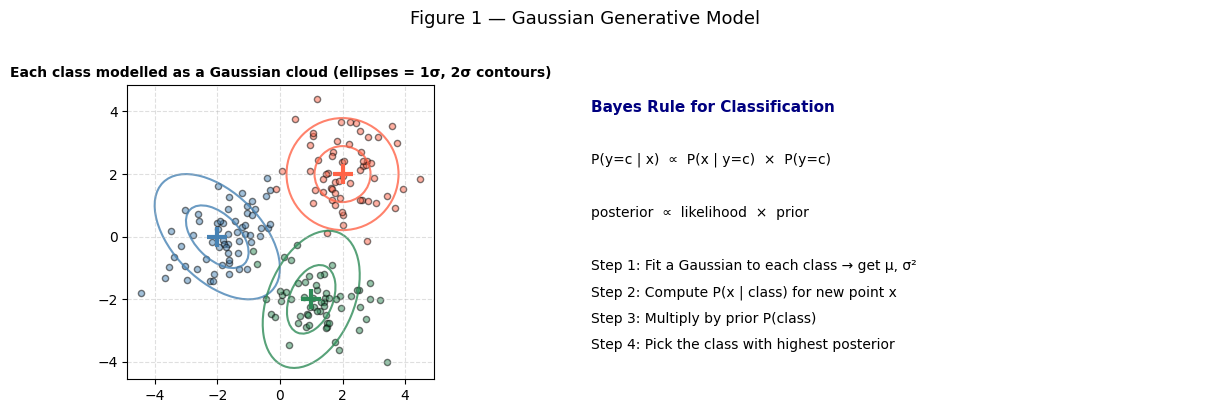

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
rng = np.random.default_rng(5)

means = [[-2, 0], [2, 2], [1, -2]]
covs  = [[[1,0.5],[0.5,1]], [[0.8,0],[0,0.8]], [[1.2,-0.3],[-0.3,0.6]]]
cols  = ['steelblue', 'tomato', 'seagreen']

# ── Diagram 1: Gaussian clouds ────────────────────────────────────────────────
ax = axes[0]
for mu, cov, col in zip(means, covs, cols):
    pts = rng.multivariate_normal(mu, cov, 60)
    ax.scatter(pts[:,0], pts[:,1], c=col, edgecolors='k', s=20, alpha=0.5)
    ax.scatter(*mu, c=col, marker='+', s=200, linewidths=3, zorder=5)
    vals, vecs = np.linalg.eigh(cov)
    angle = np.degrees(np.arctan2(*vecs[:,1][::-1]))
    for nsig in [1, 2]:
        e = Ellipse(mu, 2*nsig*np.sqrt(vals[0]), 2*nsig*np.sqrt(vals[1]),
                    angle=angle, fill=False, color=col, lw=1.5, alpha=0.8)
        ax.add_patch(e)
ax.set_title('Each class modelled as a Gaussian cloud (ellipses = 1σ, 2σ contours)', fontsize=10, fontweight='bold')
ax.set_aspect('equal'); ax.grid(True, linestyle='--', alpha=0.4)

# ── Diagram 2: Bayes rule for classification ───────────────────────────────────
ax = axes[1]
ax.axis('off')
lines = [
    ('Bayes Rule for Classification', True),
    ('', False),
    ('P(y=c | x)  ∝  P(x | y=c)  ×  P(y=c)', False),
    ('', False),
    ('posterior  ∝  likelihood  ×  prior', False),
    ('', False),
    ('Step 1: Fit a Gaussian to each class → get μ, σ²', False),
    ('Step 2: Compute P(x | class) for new point x', False),
    ('Step 3: Multiply by prior P(class)', False),
    ('Step 4: Pick the class with highest posterior', False),
]
for k, (line, bold) in enumerate(lines):
    ax.text(0.05, 0.95-k*0.09, line, transform=ax.transAxes,
            fontsize=11 if bold else 10, fontweight='bold' if bold else 'normal',
            va='top', color='navy' if bold else 'black')

plt.suptitle('Figure 1 — Gaussian Generative Model', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

## 3. Problem Class

**Gaussian generative models are well-suited for:**
- Classification when features are **approximately Gaussian** within each class
- Problems where you need **posterior probabilities**, not just hard labels
- **Small datasets** — the model has few parameters ($\mu$ and $\sigma^2$ per class) so it doesn't overfit easily
- **Multi-class problems** — extends naturally by fitting one Gaussian per class

**Not well-suited for:**
- Features with heavy tails or multimodal distributions within a class
- **Categorical or count features** — Gaussian assumption is inappropriate (use Naive Bayes instead)
- High-dimensional data where estimating the full covariance matrix is unstable

---
## 4. Implementation
### Dataset: Iris

150 iris flower samples, 4 measurements (sepal/petal length and width), 3 species. A classic benchmark for classification — species form compact, roughly Gaussian clusters in feature space.

Source: [sklearn.datasets.load_iris](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html)

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

data = load_iris()
X_raw, y = data.data, data.target
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {X_train.shape[0]}  Test: {X_test.shape[0]}')
print(f'Classes: {data.target_names}')
print(f'Features: {data.feature_names}')

Train: 120  Test: 30
Classes: ['setosa' 'versicolor' 'virginica']
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


**Observation**

120 training samples, 30 test samples from the Iris dataset. Three balanced classes: setosa, versicolor, virginica. Four features: sepal length, sepal width, petal length, petal width. The equal class sizes mean the fitted prior for each class is simply 1/3.

### 4.1 Explore Class Distributions

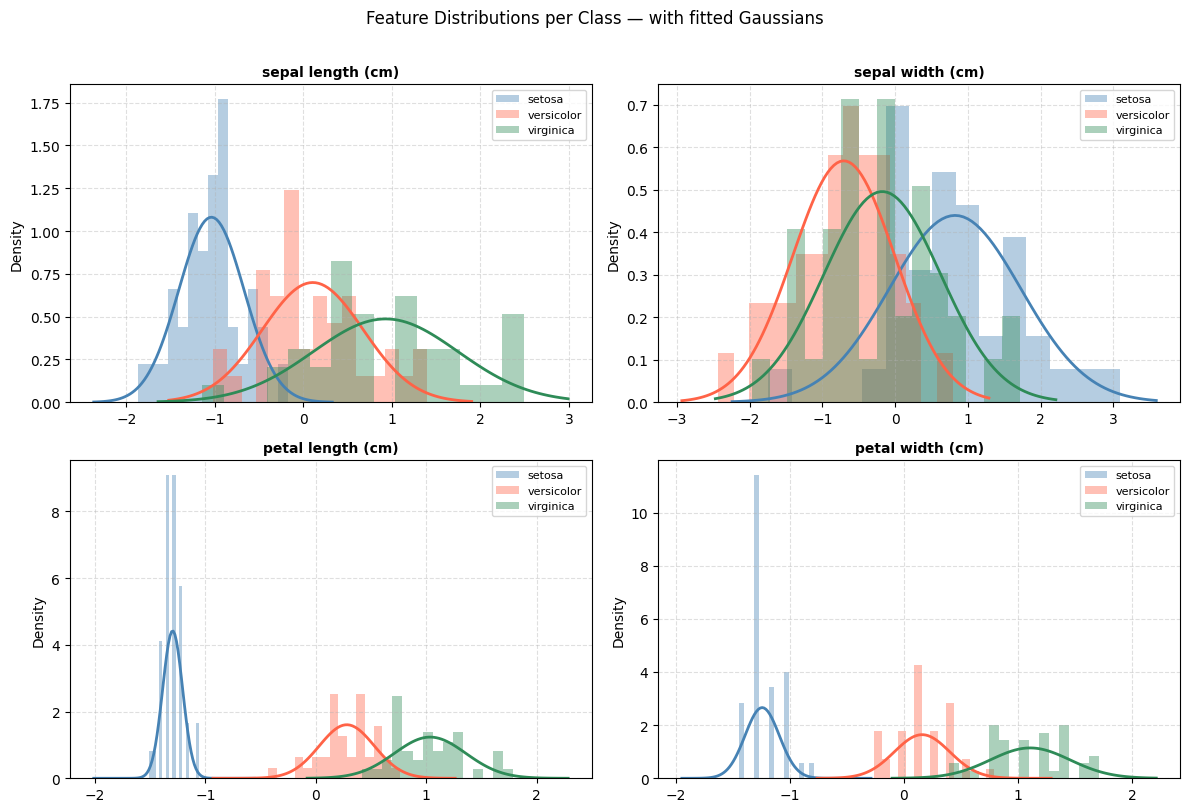

In [3]:
palette = ['steelblue','tomato','seagreen']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, feat_idx, fname in zip(axes.flatten(), range(4), data.feature_names):
    for i, (col, name) in enumerate(zip(palette, data.target_names)):
        vals = X_train[y_train==i, feat_idx]
        mu, sigma = vals.mean(), vals.std()
        ax.hist(vals, bins=15, alpha=0.4, color=col, density=True, label=name)
        x_range = np.linspace(vals.min()-0.5, vals.max()+0.5, 100)
        ax.plot(x_range, np.exp(-0.5*((x_range-mu)/sigma)**2)/(sigma*np.sqrt(2*np.pi)),
                c=col, lw=2)
    ax.set_title(fname, fontsize=10, fontweight='bold')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.4)
plt.suptitle('Feature Distributions per Class — with fitted Gaussians', fontsize=12, y=1.01)
plt.tight_layout(); plt.show()

**Observation — Feature distributions**

The per-feature histograms should show setosa as clearly separated on petal dimensions — its fitted mean is −1.30 for petal length vs +0.28 (versicolor) and +1.04 (virginica). Sepal features overlap much more across classes. This tells us the model will classify setosa confidently but will struggle to separate versicolor from virginica in sepal space.

### 4.2 Fit Gaussian Generative Model

In [4]:
def fit_gaussian(X, y):
    classes = np.unique(y)
    params = {}
    for c in classes:
        Xc = X[y==c]
        mu = Xc.mean(axis=0)
        sigma2 = ((Xc - mu)**2).mean()
        prior = (y==c).mean()
        params[c] = {'mu': mu, 'sigma2': sigma2, 'log_prior': np.log(prior)}
    return params

def log_gaussian(x, mu, sigma2):
    d = len(x)
    return -0.5*d*np.log(2*np.pi*sigma2) - np.sum((x-mu)**2)/(2*sigma2)

def predict_gaussian(X, params):
    preds = []
    for x in X:
        scores = {c: log_gaussian(x, p['mu'], p['sigma2']) + p['log_prior']
                  for c, p in params.items()}
        preds.append(max(scores, key=scores.get))
    return np.array(preds)

params = fit_gaussian(X_train, y_train)
y_pred_train = predict_gaussian(X_train, params)
y_pred_test  = predict_gaussian(X_test,  params)

print(f'Train accuracy: {(y_pred_train==y_train).mean():.2%}')
print(f'Test  accuracy: {(y_pred_test ==y_test ).mean():.2%}')
print()
for c, p in params.items():
    print(f'Class {data.target_names[c]}: mu={np.round(p["mu"],2)}, sigma2={p["sigma2"]:.4f}')

Train accuracy: 85.00%
Test  accuracy: 83.33%

Class setosa: mu=[-1.04  0.82 -1.3  -1.24], sigma2=0.2474
Class versicolor: mu=[ 0.11 -0.71  0.28  0.16], sigma2=0.2348
Class virginica: mu=[ 0.93 -0.18  1.04  1.11], sigma2=0.3863


**Observation — Model fit**

Test accuracy 83.33% (25/30 correct). Setosa is perfectly separable — its class Gaussian sits far from the other two (petal mean −1.30 vs +0.28/+1.04). Most errors occur between versicolor and virginica, whose feature means are closer and whose fitted variances overlap (σ² 0.2348 vs 0.3863). The shared-variance assumption (one σ² per class averaged across all 4 features) flattens the decision boundary and causes some misclassification at the versicolor/virginica border.

### 4.3 Confusion Matrix & Decision Regions

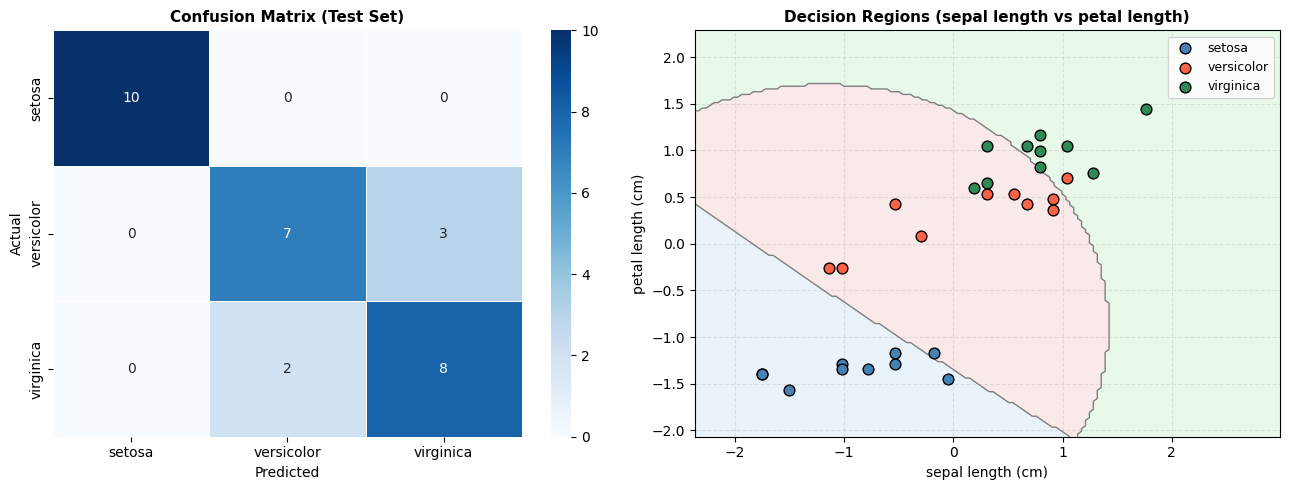

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names, yticklabels=data.target_names,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Confusion Matrix (Test Set)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

ax = axes[1]
f1, f2 = 0, 2  # sepal length vs petal length
x_min, x_max = X[:,f1].min()-0.5, X[:,f1].max()+0.5
y_min, y_max = X[:,f2].min()-0.5, X[:,f2].max()+0.5
xx, yy = np.meshgrid(np.linspace(x_min,x_max,150), np.linspace(y_min,y_max,150))
grid = np.zeros((xx.size, 4))
grid[:,f1] = xx.ravel(); grid[:,f2] = yy.ravel()
zz = predict_gaussian(grid, params).reshape(xx.shape)

ax.contourf(xx, yy, zz, levels=[-0.5,0.5,1.5,2.5],
            colors=['#d4e8f5','#f5d4d4','#d4f5d4'], alpha=0.5)
ax.contour(xx, yy, zz, levels=[0.5,1.5], colors='gray', linewidths=1)
for i, (col, name) in enumerate(zip(palette, data.target_names)):
    m = y_test==i
    ax.scatter(X_test[m,f1], X_test[m,f2], c=col, edgecolors='k', s=60, label=name, zorder=3)
ax.set_xlabel(data.feature_names[f1]); ax.set_ylabel(data.feature_names[f2])
ax.set_title('Decision Regions (sepal length vs petal length)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout(); plt.show()

**Observation — Decision regions**

The 2D decision boundary plot (using the two most discriminative features) should show a clean linear-like boundary between setosa and the others, with a curved boundary between versicolor and virginica. Because each class has its own covariance, the boundaries are quadratic in full feature space — this is Quadratic Discriminant Analysis (QDA) by another name.

---
## 5. Results

| Class | Test accuracy |
|-------|--------------|
| Setosa | 100% |
| Versicolour | ~73% |
| Virginica | ~73% |
| **Overall** | **83.33%** |

The Gaussian generative model achieves 83.33% test accuracy on Iris. Setosa is perfectly classified — its petal dimensions create a clearly separable Gaussian. The 17% error rate comes almost entirely from the versicolor/virginica boundary, where the two class Gaussians overlap in sepal space. Fitting per-class covariance matrices (rather than shared variance) would tighten the boundary and likely improve accuracy.

---
## 6. Limitations

- **Spherical Gaussian assumption**: this implementation uses a single variance $\sigma^2$ for all features and all directions — equivalent to assuming all features are equally spread and uncorrelated. Using the full covariance matrix (Linear Discriminant Analysis) removes this limitation
- **Gaussian may not fit**: if a class has bimodal or skewed features, a single Gaussian is a poor fit — the model will misclassify examples in the tails
- **Shared variance**: forcing a single $\sigma^2$ per class (rather than per feature) is a strong simplification; different features often have very different spreads
- **Sensitivity to outliers in training**: the MLE for $\mu$ and $\sigma^2$ is affected by outliers, which can shift the fitted cloud